In [1]:
pip install -qq pandas matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
datafile=pd.read_csv ("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/sleep.csv")
datafile.groupby('group').describe()

A                                                extra        ...  \
      count  mean      std   min    25%   50%    75%   max count  mean  ...   
group                                                                   ...   
1      10.0   5.5  3.02765   1.0   3.25   5.5   7.75  10.0  10.0  0.75  ...   
2      10.0  15.5  3.02765  11.0  13.25  15.5  17.75  20.0  10.0  2.33  ...   

                    ID                                            
        75%  max count mean      std  min   25%  50%   75%   max  
group                                                             
1      1.70  3.7  10.0  5.5  3.02765  1.0  3.25  5.5  7.75  10.0  
2      4.15  5.5  10.0  5.5  3.02765  1.0  3.25  5.5  7.75  10.0  

[2 rows x 24 columns]

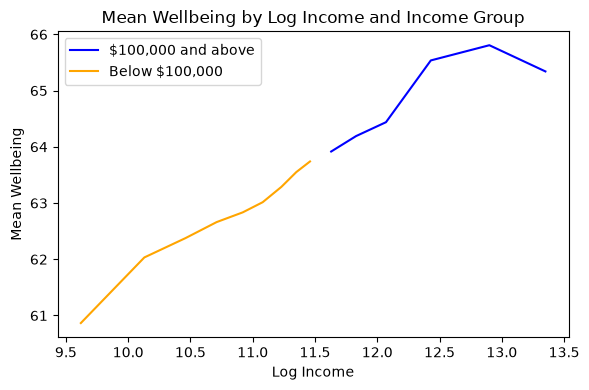

In [5]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
source=pd.read_csv ("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/Income2023.csv")
# Aggregate at each observed income value for a readable reproduction of the fitted relationships.
figure_2 = (source.groupby(['income_above_100','income','log_income'], as_index=False)
            .agg(mean_wellbeing=('wellbeing','mean'), n=('wellbeing','size')))
figure_2['income_group'] = np.where(figure_2['income_above_100'].eq(1), '$100,000 and above', 'Below $100,000')
figure_2 = figure_2.sort_values(['income_group','log_income'])
plt.figure(figsize=(6, 4))
plt.plot(figure_2.query("income_group == '$100,000 and above'")['log_income'],
         figure_2.query("income_group == '$100,000 and above'")['mean_wellbeing'], label='$100,000 and above', color='blue')
plt.plot(figure_2.query("income_group == 'Below $100,000'")['log_income'],
         figure_2.query("income_group == 'Below $100,000'")['mean_wellbeing'], label='Below $100,000', color='orange')
plt.xlabel('Log Income')
plt.ylabel('Mean Wellbeing')
plt.title('Mean Wellbeing by Log Income and Income Group')
plt.legend()
plt.tight_layout()
#plt.savefig("C:\\2023_income_wellbeing.png", dpi=300)
plt.show()

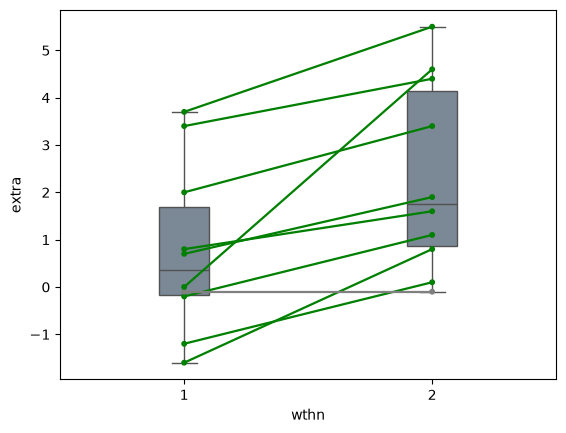

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
datafile=pd.read_csv ("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/sleep.csv")
#display (datafile.groupby('group').describe())
summary1 = (
    datafile.groupby("group")["extra"]
      .agg(
          mean="mean",
          std="std", #se=lambda x: x.sem(),
          #n="count"
      )
      .reset_index()
)
#print(summary)

#print (datafile["group"].dtype)
summary=datafile.groupby("group")["extra"].agg(["mean", "std"]).reset_index()
#summary["group"] = summary["group"].astype(str)
#plt.bar(summary["group"], summary["mean"], yerr=summary["std"], capsize=5)
#plt.xticks([1, 2], ["Control", "Treatment"])
#plt.ylabel("Extra Sleep (hours)")
#plt.show()
ax = pg.plot_paired(data=datafile, dv='extra', within='group', subject='ID') #, errorbar='se', pointplot=True, paired=True)


<Axes: ylabel='Frequency'>

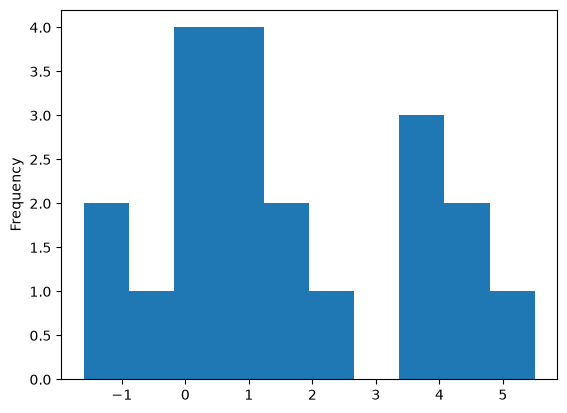

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
# Histogram
datafile["extra"].plot(kind="hist")